# Comparing covariance solutions across trained networks

Train four networks on shared trials, then compare their connectivity covariance and held-out population trajectories. Keeping training separate makes the analysis cell fast to rerun.


In [1]:
from contextlib import redirect_stdout
import io

import numpy as np
import torch

from low_rank_rnn.data import generate_perceptual_decision_making_trials
from low_rank_rnn.model import RankOneRNN
from low_rank_rnn.training import train_model

# Train on one shared dataset so the comparison isolates initialization differences.
n_networks = 4
n_train_trials = 150
n_trajectory_trials = 40
n_epochs = 300
base_seed = 2026

train_data, train_targets = generate_perceptual_decision_making_trials(
    num_trials=n_train_trials,
    rng=np.random.default_rng(base_seed),
)
train_inputs = torch.tensor(train_data, dtype=torch.float32)
train_labels = torch.tensor(train_targets, dtype=torch.float32)

trajectory_data, trajectory_targets = generate_perceptual_decision_making_trials(
    num_trials=n_trajectory_trials,
    rng=np.random.default_rng(base_seed + 10_000),
)
trajectory_inputs = torch.tensor(trajectory_data, dtype=torch.float32)
trajectory_labels = torch.tensor(trajectory_targets, dtype=torch.float32)

comparison_models = []
comparison_losses = []
for network_index in range(n_networks):
    torch.manual_seed(base_seed + network_index)
    network = RankOneRNN(n_units=128)
    with redirect_stdout(io.StringIO()):
        losses = train_model(
            network,
            train_inputs,
            train_labels,
            epochs=n_epochs,
            batch_size=32,
        )
    comparison_models.append(network)
    comparison_losses.append(losses)

final_losses = [losses[-1] for losses in comparison_losses]
print("Final losses:", [f"{loss:.2e}" for loss in final_losses])


Final losses: ['1.14e-04', '1.52e-04', '9.28e-05', '1.57e-04']


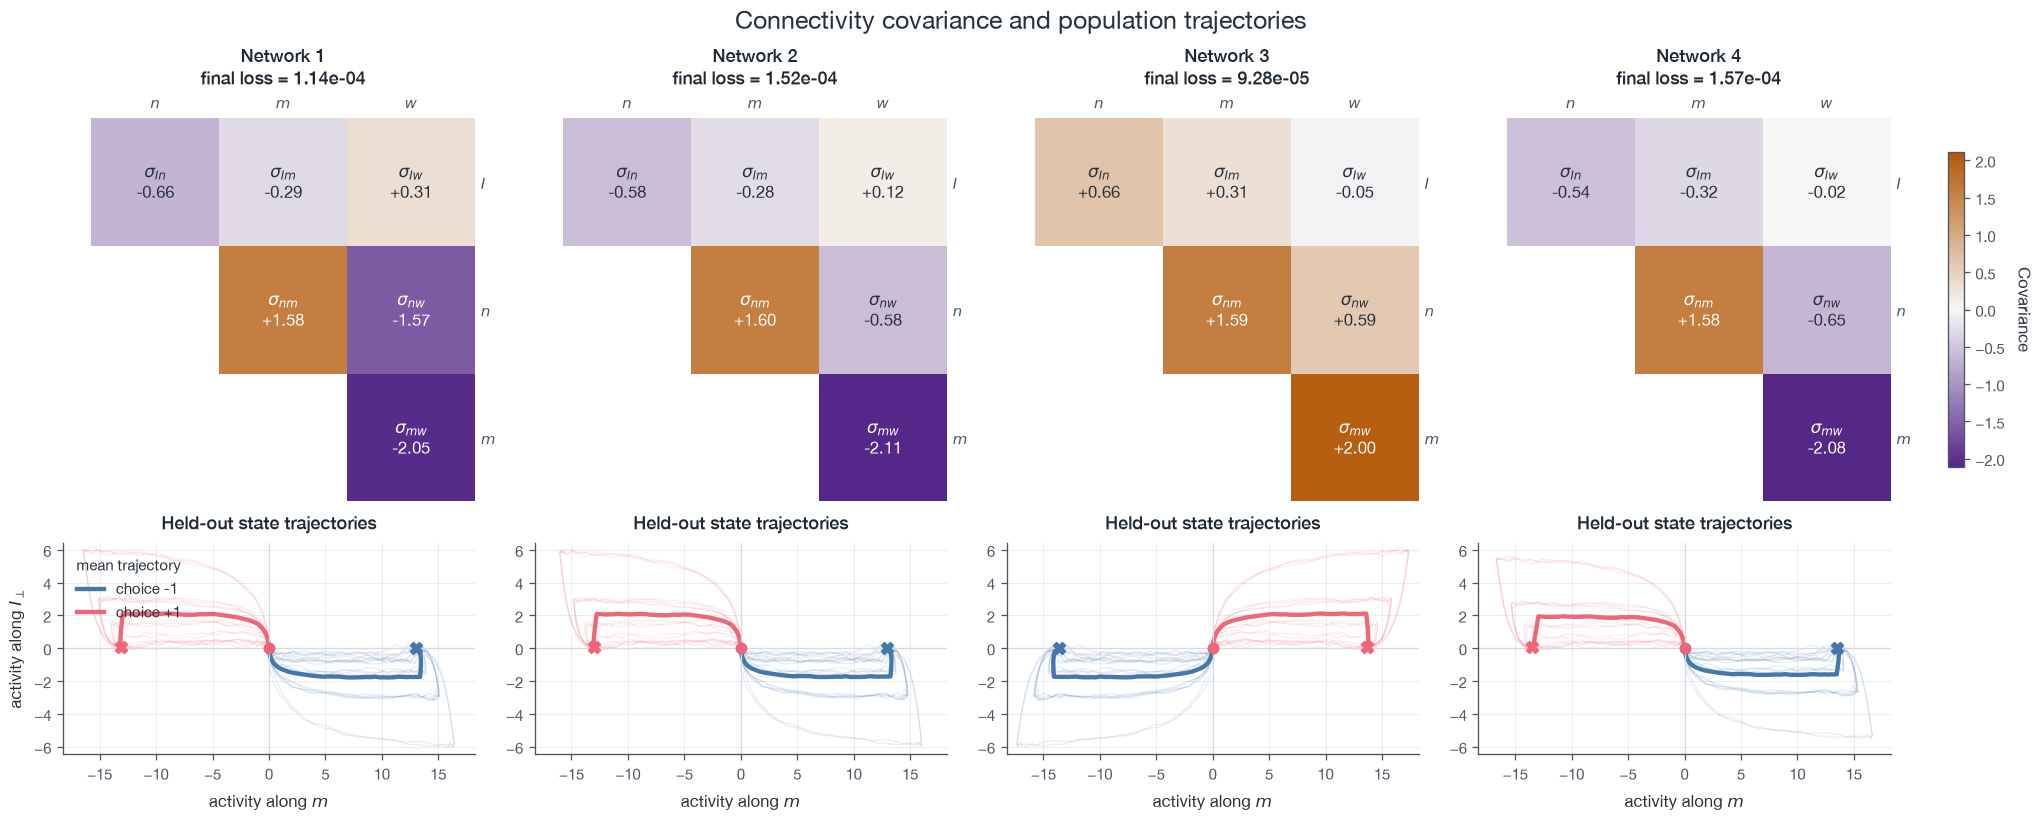

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from low_rank_rnn.analysis import (
    connectivity_covariance,
    connectivity_vectors,
    project_rank_one_activity,
)
from low_rank_rnn.plotting import (
    CHOICE_COLORS,
    COVARIANCE_CMAP,
    activity_trajectory_limits,
    set_plot_style,
)

set_plot_style()

comparison_covariances = []
projected_trajectories = []
for network in comparison_models:
    covariance_names, covariance = connectivity_covariance(
        connectivity_vectors(network)
    )
    comparison_covariances.append(covariance)

    was_training = network.training
    network.eval()
    with torch.no_grad():
        _, trajectory_states = network(trajectory_inputs)
    network.train(was_training)
    projected_trajectories.append(
        project_rank_one_activity(trajectory_states, network)
    )

# Shared limits make both the covariance colors and trajectory geometry comparable.
pair_mask = np.tril(np.ones((3, 3), dtype=bool), k=-1)
visible_covariances = np.concatenate(
    [covariance[:-1, 1:][~pair_mask] for covariance in comparison_covariances]
)
color_limit = max(float(np.max(np.abs(visible_covariances))), 1e-12)

stacked_trajectories = np.stack(projected_trajectories)
trajectory_x_limits, trajectory_y_limits = activity_trajectory_limits(
    stacked_trajectories
)
trajectory_choices = trajectory_labels.cpu().numpy().astype(int)

fig, axes = plt.subplots(
    2,
    n_networks,
    figsize=(17, 6.8),
    gridspec_kw={"height_ratios": (1, 0.55)},
    constrained_layout=True,
)

for network_index, covariance in enumerate(comparison_covariances):
    pair_covariances = covariance[:-1, 1:]
    axis = axes[0, network_index]
    image = axis.imshow(
        np.ma.masked_array(pair_covariances, mask=pair_mask),
        cmap=COVARIANCE_CMAP,
        vmin=-color_limit,
        vmax=color_limit,
    )
    axis.set_xticks(
        range(3),
        labels=[rf"${name}$" for name in covariance_names[1:]],
    )
    axis.set_yticks(
        range(3),
        labels=[rf"${name}$" for name in covariance_names[:-1]],
    )
    axis.xaxis.tick_top()
    axis.yaxis.tick_right()
    axis.tick_params(length=0)
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(False)

    for row, first_name in enumerate(covariance_names[:-1]):
        for column in range(row, 3):
            second_name = covariance_names[column + 1]
            value = pair_covariances[row, column]
            text_color = "white" if abs(value) > 0.55 * color_limit else "#27313B"
            axis.text(
                column,
                row,
                rf"$\sigma_{{{first_name}{second_name}}}$" + f"\n{value:+.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=10,
            )
    axis.set_title(
        f"Network {network_index + 1}\nfinal loss = {comparison_losses[network_index][-1]:.2e}",
        pad=20,
    )

    axis = axes[1, network_index]
    projected_states = projected_trajectories[network_index]
    for choice, color in CHOICE_COLORS.items():
        choice_trajectories = projected_states[trajectory_choices == choice]
        for trajectory in choice_trajectories:
            axis.plot(
                trajectory[:, 0],
                trajectory[:, 1],
                color=color,
                alpha=0.12,
                linewidth=0.8,
            )

        mean_trajectory = choice_trajectories.mean(axis=0)
        axis.plot(
            mean_trajectory[:, 0],
            mean_trajectory[:, 1],
            color=color,
            linewidth=2.6,
            label=f"choice {choice:+d}",
        )
        arrow_times = np.arange(0, len(mean_trajectory) - 1, 10)
        trajectory_steps = np.diff(mean_trajectory, axis=0)
        axis.quiver(
            mean_trajectory[arrow_times, 0],
            mean_trajectory[arrow_times, 1],
            trajectory_steps[arrow_times, 0],
            trajectory_steps[arrow_times, 1],
            color=color,
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.006,
        )
        axis.scatter(*mean_trajectory[0], color=color, marker="o", s=35, zorder=3)
        axis.scatter(*mean_trajectory[-1], color=color, marker="X", s=50, zorder=3)

    axis.axhline(0, color="0.85", linewidth=0.8)
    axis.axvline(0, color="0.85", linewidth=0.8)
    axis.set_xlim(*trajectory_x_limits)
    axis.set_ylim(*trajectory_y_limits)
    axis.set_aspect("auto")
    axis.set_xlabel(r"activity along $m$")
    axis.set_title("Held-out state trajectories")
    if network_index == 0:
        axis.set_ylabel(r"activity along $I_\perp$")
        axis.legend(title="mean trajectory", loc="upper left")

colorbar = fig.colorbar(
    image,
    ax=axes[0].tolist(),
    shrink=0.82,
    pad=0.02,
)
colorbar.set_label("Covariance", rotation=270, labelpad=18)
fig.suptitle(
    "Connectivity covariance and population trajectories",
    fontsize=15,
)
plt.show()


### How the covariance structure performs the decision task

For the rank-one network, define the latent activity and readout as

$$
\kappa(t)=\frac{1}{N}n^\top\phi(x(t)),
\qquad
z(t)=\frac{1}{N}w^\top\phi(x(t)),
$$

so the population dynamics are

$$
\tau\dot{x}=-x+m\kappa+Iu(t).
$$

Near the linear regime, projection onto $n$ gives the approximate one-dimensional dynamics

$$
\tau\dot{\kappa}\approx
\left(-1+\langle n,m\rangle\right)\kappa
+\langle n,I\rangle u(t),
\qquad
z(t)\approx\langle w,m\rangle\kappa(t)+\langle w,I\rangle u(t),
$$

where $\langle a,b\rangle=a^\top b/N$ is approximately the covariance when the vectors are centered. Thus $\langle n,I\rangle$ injects sensory evidence into the latent state, positive $\langle n,m\rangle$ supplies recurrent feedback that integrates and maintains the choice, and $\langle w,m\rangle$ maps the latent state to the readout.

Both observed sign patterns produce the correct decision because

$$
\operatorname{sign}\!\left(\frac{z}{u}\right)
\approx
\operatorname{sign}\!\left(\langle n,I\rangle\langle w,m\rangle\right)>0.
$$

The direct solution has both factors positive; the flipped solution has both negative. Simultaneously changing $m\to-m$ and $n\to-n$ leaves the effective recurrent connectivity $mn^\top/N$ unchanged, so the two solutions differ only in the orientation assigned to the latent axis.
